In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy
from statsmodels.graphics.tsaplots import plot_acf, acf
from matplotlib.ticker import PercentFormatter
from scipy.integrate import quad
from math import cos, sqrt
import pandas as pd
import yaml
SEED = 49
random.seed(SEED)
np.random.seed(SEED)
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/"


In [2]:
trajectory_ID = 0
trajectory = np.load(results_path + f"data/trajectory{trajectory_ID}.npz")
with open(results_path + f"data/trajectory{trajectory_ID}.yaml", "r") as f:
    config = yaml.safe_load(f)
z_full = trajectory["z"]
x_full = trajectory["x"]

length = config["length"]
initial_distribution_variance = config["initial_distribution_variance"]
sigma_true = config["sigma_true"]
sigma2_true = config["sigma2_true"]
rho_true = config["rho_true"]
beta_true = config["beta_true"]
beta2_true = config["beta2_true"]

In [4]:
# Truncate data
#T = 30
z = z_full[:30+1]
x = x_full[:30+1]

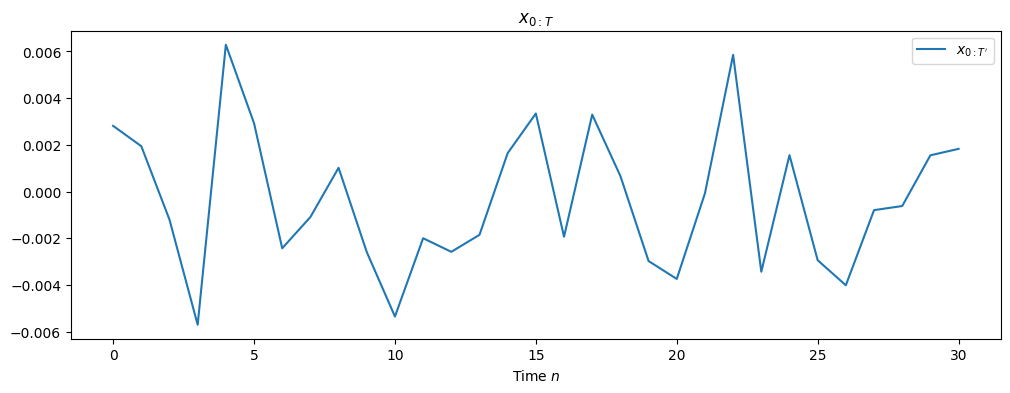

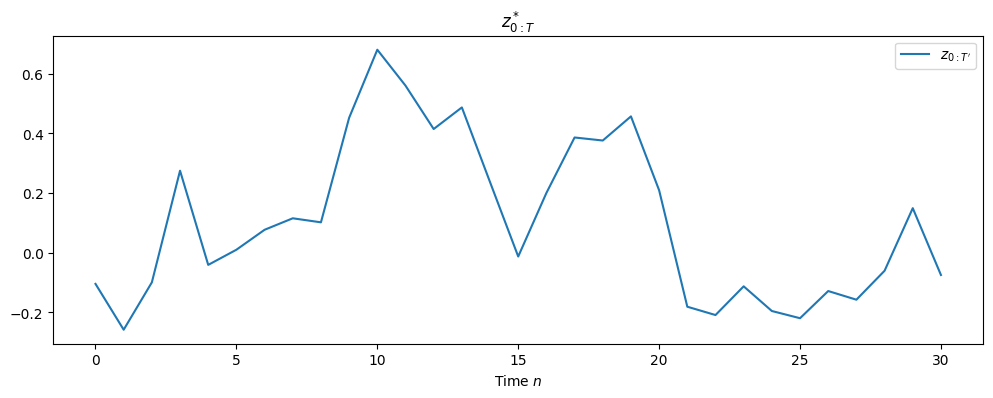

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
#ax.plot(x, label=r"$x_{0:T'}$")
ax.plot(x, label=r"$x_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"$x_{0:T}$")
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(z, label=r"$z_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"$z^*_{0:T}$")
plt.show()

In [ ]:
def f_rv(z_nm1, sigma, rho):
    return rho * z_nm1 + sigma * np.random.randn(len(z_nm1))

def f_pdf(z_n, z_nm1, sigma, rho):
    return scipy.stats.norm.pdf(z_n, loc=rho * z_nm1, scale=sigma)

def eta_rv(dim=1, initial_distribution_variance=0.01):
    return sqrt(initial_distribution_variance) * np.random.randn(dim)

def eta_pdf(z_0, initial_distribution_variance):
    return scipy.stats.norm.pdf(z_0, loc=0, scale=sqrt(initial_distribution_variance))

def q_rv(z_nm1, sigma, rho):
    return f_rv(z_nm1, sigma, rho)

def q_pdf(z_n, z_nm1, sigma, rho):
    return f_pdf(z_n, z_nm1, sigma, rho)

def q0_rv(dim=1, initial_distribution_variance=0.01):
    return eta_rv(dim, initial_distribution_variance)

def q0_pdf(z_0, initial_distribution_variance=0.01):
    return eta_pdf(z_0, initial_distribution_variance)

def g_rv(z_n, beta):
    return beta * np.exp(z_n / 2) * np.random.randn(len(z_n))

def g_pdf(x_n, z_n, beta):
    return scipy.stats.norm.pdf(x_n, loc=0, scale=beta * np.exp(z_n / 2))

def transition_matrix(Zkp1_samples, Zk_candidates, weights, N, M, k, sigma, rho):
    transition_matrix = np.zeros((M, N))
    for i in range(M):
        for j in range(N):
            Wk_j = weights[j, k]
            Zkp1_i = Zkp1_samples[i]
            Zk_j = Zk_candidates[j]
            unnormalized_transition_prob_i_to_j = Wk_j * f_pdf(Zkp1_i, Zk_j, sigma, rho)
            transition_matrix[i, j] = unnormalized_transition_prob_i_to_j
    transition_matrix = transition_matrix / np.sum(transition_matrix, axis=1, keepdims=True)
    return transition_matrix


def SIR_loglikelihood(n, N, x, sigma, beta, rho, print_ks=False, return_FFBSa_sample=False, initial_distribution_variance=0.01):
    sample_paths_forwards = np.zeros((N, n+1))
    weights = np.zeros((N, n+1))
    points_grid = np.zeros((N, n+1))

    Z0_samples = q0_rv(dim=N, initial_distribution_variance=initial_distribution_variance)
    points_grid[:, 0] = Z0_samples
    log_w0 = scipy.stats.norm.logpdf(x[0], loc=0, scale=beta * np.exp(Z0_samples/2))
    logllk = scipy.special.logsumexp(log_w0) - np.log(N)

    w0 = np.exp(log_w0 - np.max(log_w0))
    w0_normalized = w0/np.sum(w0)
    weights[:, 0] = w0_normalized
    resample_idx = np.random.choice(N, size=N, p=w0_normalized)
    Z0_samples = Z0_samples[resample_idx]
    sample_paths_forwards[:,0] = Z0_samples

    for k in range(1, n+1):
        Zkm1_samples = sample_paths_forwards[:, k-1]
        Zk_samples = q_rv(Zkm1_samples, sigma=sigma, rho=rho)
        points_grid[:, k] = Zk_samples
        sample_paths_forwards[:,k] = Zk_samples
        log_wk = scipy.stats.norm.logpdf(x[k], loc=0, scale=beta * np.exp(Zk_samples/2))
        logllk += scipy.special.logsumexp(log_wk) - np.log(N)

        wk = np.exp(log_wk - np.max(log_wk))
        wk_normalized = wk/np.sum(wk)
        weights[:, k] = wk_normalized

        resample_idx = np.random.choice(N, size=N, p=wk_normalized)
        sample_paths_forwards = sample_paths_forwards[resample_idx]

    if not return_FFBSa_sample:
        return logllk

    M = 1

    sample_paths_backward = np.zeros((M, n+1))
    sample_idxs = np.zeros((M, n+1))

    probs_n = weights[:, n]
    Zn_samples_idx = np.random.choice(N, size=M, p=probs_n)
    sample_idxs[:, n] = Zn_samples_idx

    Zn_samples = points_grid[:,n][Zn_samples_idx]
    sample_paths_backward[:, n] = Zn_samples

    for k in reversed(range(0, n)):
        if print_ks:
            print(f"k = {k}")
        Zkp1_samples = sample_paths_backward[:, k+1]
        Zkp1_samples_idx = sample_idxs[:, k+1]
        Zk_candidates = points_grid[:, k]
        transition_matrix_k = transition_matrix(Zkp1_samples, Zk_candidates, weights, N, M, k, sigma, rho)
        cdf = np.cumsum(transition_matrix_k, axis=1)
        r = np.random.rand(len(Zkp1_samples_idx), 1)
        Zk_samples_idx = (cdf > r).argmax(axis=1)
        sample_idxs[:, k] = Zk_samples_idx
        Zk_samples = points_grid[:,k][Zk_samples_idx.astype(int)]
        sample_paths_backward[:, k] = Zk_samples

    return logllk, sample_paths_backward


def prior_rv(sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper):
    sigma2 = scipy.stats.invgamma.rvs(a=sigma2_alpha, scale=sigma2_beta)
    beta2 = scipy.stats.invgamma.rvs(a=beta2_alpha,  scale=beta2_beta)
    rho = scipy.stats.uniform.rvs(loc=rho_lower, scale=rho_upper - rho_lower)
    return np.array([sigma2, beta2, rho])


def prior_logpdf(sigma2, beta2, rho, sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper):
    p_sigma2 = scipy.stats.invgamma.logpdf(sigma2, a=sigma2_alpha, scale=sigma2_beta)
    p_beta2  = scipy.stats.invgamma.logpdf(beta2,  a=beta2_alpha,  scale=beta2_beta)
    p_rho    = scipy.stats.uniform.logpdf(rho, loc=rho_lower, scale=rho_upper - rho_lower)
    return p_sigma2 + p_beta2 + p_rho


def prior_pdf(sigma2, beta2, rho, sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper):
    p_sigma2 = scipy.stats.invgamma.pdf(sigma2, a=sigma2_alpha, scale=sigma2_beta)
    p_beta2  = scipy.stats.invgamma.pdf(beta2,  a=beta2_alpha,  scale=beta2_beta)
    p_rho    = scipy.stats.uniform.pdf(rho, loc=rho_lower, scale=rho_upper - rho_lower)
    return p_sigma2 * p_beta2 * p_rho


def proposal_rv(theta_old, step_sizes=(0.01, 5e-6, 0.01)):
    """Theta is a np array of length 3"""
    step_sizes = np.array(step_sizes)
    return theta_old + step_sizes * np.random.randn(3)


def proposal_logpdf(theta_new, theta_old, step_sizes=(0.01, 5e-6, 0.01)):
    """Thetas are np arrays of length 3"""
    step_sizes = np.array(step_sizes)
    return scipy.stats.multivariate_normal.logpdf(theta_new, mean=theta_old, cov=np.diag(step_sizes**2))


def PMMH_step_sample_trajectories(x, T, theta_km1, loglikelihood_km1, z_0_to_T_km1, N, sigma2_alpha,
                                  sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper,
                                  step_sizes=(0.01, 5e-6, 0.01), print_ks=False):
    theta_k = proposal_rv(theta_km1, step_sizes=step_sizes)
    sigma2_k, beta2_k, rho_k = theta_k
    if (sigma2_k <= 0) or (beta2_k <= 0) or (rho_k <= rho_lower) or (rho_k >= rho_upper):
        return theta_km1, loglikelihood_km1, z_0_to_T_km1, 0
    loglikelihood_k, z_0_to_T_k = SIR_loglikelihood(T, N, x, sqrt(sigma2_k), sqrt(beta2_k), rho_k, print_ks=print_ks, return_FFBSa_sample=True)
    sigma2_km1, beta2_km1, rho_km1 = theta_km1
    log_alpha = (
                loglikelihood_k + prior_logpdf(sigma2_k, beta2_k, rho_k,
                                               sigma2_alpha, sigma2_beta, beta2_alpha,
                                               beta2_beta, rho_lower, rho_upper)
              - loglikelihood_km1 - prior_logpdf(sigma2_km1, beta2_km1, rho_km1,
                                                 sigma2_alpha, sigma2_beta, beta2_alpha,
                                                 beta2_beta, rho_lower, rho_upper)
                )
    acceptance_prob = min(1, np.exp(log_alpha))
    if np.random.rand() < acceptance_prob:
        return theta_k, loglikelihood_k, z_0_to_T_k, acceptance_prob
    else:
        return theta_km1, loglikelihood_km1, z_0_to_T_km1, acceptance_prob


def PMMH_step(x, T, theta_km1, loglikelihood_km1, N, sigma2_alpha, sigma2_beta,
              beta2_alpha, beta2_beta, rho_lower, rho_upper, step_sizes=(0.01, 5e-6, 0.01)):
    theta_k = proposal_rv(theta_km1, step_sizes=step_sizes)
    sigma2_k, beta2_k, rho_k = theta_k
    if (sigma2_k <= 0) or (beta2_k <= 0) or (rho_k <= rho_lower) or (rho_k >= rho_upper):
        return theta_km1, loglikelihood_km1, 0
    loglikelihood_k = SIR_loglikelihood(T, N, x, sqrt(sigma2_k), sqrt(beta2_k), rho_k, return_FFBSa_sample=False)
    sigma2_km1, beta2_km1, rho_km1 = theta_km1
    log_alpha = (
                loglikelihood_k + prior_logpdf(sigma2_k, beta2_k, rho_k, sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper)
              - loglikelihood_km1 - prior_logpdf(sigma2_km1, beta2_km1, rho_km1, sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper)
                )
    acceptance_prob = min(1, np.exp(log_alpha))
    if np.random.rand() < acceptance_prob:
        return theta_k, loglikelihood_k, acceptance_prob
    else:
        return theta_km1, loglikelihood_km1, acceptance_prob


def generate_PMMH_samples(x, T, num_iterations, N, step_sizes, sigma2_alpha, sigma2_beta,
                          beta2_alpha, beta2_beta, rho_lower, rho_upper,
                          theta_0=None, sample_trajectories=False, print_ks=False):
    if theta_0 is None:
        theta_0 = prior_rv(sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper)
    sigma2_0, beta2_0, rho_0 = theta_0
    if sample_trajectories:
        loglikelihood_0, z_0_to_T_0 = SIR_loglikelihood(T, N, x, sqrt(sigma2_0), sqrt(beta2_0), rho_0, print_ks=print_ks, return_FFBSa_sample=True)
    else:
        loglikelihood_0 = SIR_loglikelihood(T, N, x, sqrt(sigma2_0), sqrt(beta2_0), rho_0, print_ks=print_ks, return_FFBSa_sample=False)

    thetas = [theta_0]
    loglikelihoods = [loglikelihood_0]
    acceptance_ratios = [0]
    if sample_trajectories:
        z_0_to_Ts = [z_0_to_T_0]

    for k in range(1, num_iterations + 1):
        print(12*"-" + f"STEP {k}" + 12*"-")

        theta_km1 = thetas[k - 1]
        loglikelihood_km1 = loglikelihoods[k - 1]
        if sample_trajectories:
            z_0_to_T_km1 = z_0_to_Ts[k - 1]

        if sample_trajectories:
            theta_k, loglikelihood_k, z_0_to_T_k, acceptance_ratio_k = PMMH_step_sample_trajectories(x, T, theta_km1, loglikelihood_km1, z_0_to_T_km1, N, sigma2_alpha,
                                                                                                      sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper,
                                                                                                      step_sizes=step_sizes, print_ks=print_ks)
        else:
            theta_k, loglikelihood_k, acceptance_ratio_k = PMMH_step(x, T, theta_km1, loglikelihood_km1, N, sigma2_alpha, sigma2_beta, beta2_alpha, beta2_beta, rho_lower, rho_upper, step_sizes=step_sizes)

        thetas.append(theta_k)
        loglikelihoods.append(loglikelihood_k)
        acceptance_ratios.append(acceptance_ratio_k)
        if sample_trajectories:
            z_0_to_Ts.append(z_0_to_T_k)

        print(f"theta = {theta_k}")
        print(f"----- cum_logllk_var = {np.var(loglikelihoods)}")
        print(f"----- ar = {acceptance_ratio_k}")
        print(f"----- cum_mean_ar = {np.mean(acceptance_ratios)}")

    if sample_trajectories:
        return thetas, z_0_to_Ts, loglikelihoods, acceptance_ratios
    else:
        return thetas, loglikelihoods, acceptance_ratios

In [12]:
# --- Run ---
num_iterations = 50
step_sizes = (0.03, 4e-6, 0.03)
theta_0 = np.array([sigma2_true, beta2_true, rho_true])
N = 1000
sample_trajectories = True
print_ks = False

sigma2_alpha = 3
sigma2_beta = 0.04
beta2_alpha = 3
beta2_beta = 5e-5
rho_lower = 0
rho_upper = 1
T = 30

if sample_trajectories:
    thetas, z_0_to_Ts, loglikelihoods, acceptance_ratios = generate_PMMH_samples(x, T,
                                                                    num_iterations=num_iterations,
                                                                    N=N,
                                                                    step_sizes=step_sizes,
                                                                    sigma2_alpha=sigma2_alpha,
                                                                    sigma2_beta=sigma2_beta,
                                                                    beta2_alpha=beta2_alpha,
                                                                    beta2_beta=beta2_beta,
                                                                    rho_lower=rho_lower,
                                                                    rho_upper=rho_upper,
                                                                    theta_0=theta_0,
                                                                    sample_trajectories=sample_trajectories,
                                                                    print_ks=print_ks)
    z_0_to_Ts = np.array(z_0_to_Ts).squeeze(1)
else:
    thetas, loglikelihoods, acceptance_ratios = generate_PMMH_samples(x, T,
                                                                    num_iterations=num_iterations,
                                                                    N=N,
                                                                    step_sizes=step_sizes,
                                                                    sigma2_alpha=sigma2_alpha,
                                                                    sigma2_beta=sigma2_beta,
                                                                    beta2_alpha=beta2_alpha,
                                                                    beta2_beta=beta2_beta,
                                                                    rho_lower=rho_lower,
                                                                    rho_upper=rho_upper,
                                                                    theta_0=theta_0,
                                                                    sample_trajectories=sample_trajectories,
                                                                    print_ks=print_ks)

------------STEP 1------------
theta = [1.08755206e-02 8.58359452e-06 8.91356962e-01]
----- cum_logllk_var = 0.04705870532455306
----- ar = 1
----- cum_mean_ar = 0.5
------------STEP 2------------
theta = [1.08755206e-02 8.58359452e-06 8.91356962e-01]
----- cum_logllk_var = 0.04182996028849161
----- ar = 5.505161631597611e-18
----- cum_mean_ar = 0.3333333333333333
------------STEP 3------------
theta = [1.08755206e-02 8.58359452e-06 8.91356962e-01]
----- cum_logllk_var = 0.0352940289934148
----- ar = 0.7124885103191422
----- cum_mean_ar = 0.4281221275797855
------------STEP 4------------
theta = [1.08755206e-02 8.58359452e-06 8.91356962e-01]
----- cum_logllk_var = 0.030117571407713966
----- ar = 0
----- cum_mean_ar = 0.3424977020638284
------------STEP 5------------
theta = [1.08755206e-02 8.58359452e-06 8.91356962e-01]
----- cum_logllk_var = 0.02614372518030726
----- ar = 0.0003508777071673375
----- cum_mean_ar = 0.28547323133771824
------------STEP 6------------
theta = [1.08755206e-